In [72]:
import os
import codecs
# point this at wherever you extracted the archive on your machine
DATA_ROOT = "/home/praneeth/Sem5/ML/Lab4/20news-bydate" # <- your actual path
TRAIN_DIR = os.path.join(DATA_ROOT, "20news-bydate-train")
TEST_DIR = os.path.join(DATA_ROOT, "20news-bydate-test")
print(sorted(os.listdir(TRAIN_DIR))) # should list the 20 class folders
ALPHA=1

['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [73]:
file = open('en.txt','r')
words = file.read()
stopwords=set(words.split())
file.close()

In [74]:

def tokenize(text):
    text_body = text.split('\n\n')[1]
    text_words=text_body.lower().split()
    words=[]
    for word in text_words:
        word = word.strip(".,!?()[]:;")
        if word.isalpha() and len(word)>1:
            # if word not in stop_words:
            words.append(word)
    return words
    

## Q(1) (a) Load the training and test documents. For each document, remove the email-style header (the lines before the first blank line) and tokenize the remaining text into lowercase words. Train words.

In [75]:
train_list=[]
train_doc_count=[]
for folder in os.listdir(TRAIN_DIR):
    file_path = os.path.join(TRAIN_DIR,folder)
    file_list= os.listdir(file_path)
    file_tokens=[]
    train_doc_count.append(len(file_list))
    for file in file_list:
        file_path_2=os.path.join(file_path,file)
        F = codecs.open(file_path_2,'r',encoding='utf-8',errors='ignore')
        content=F.read()
        # print(content)
        tokens=tokenize(content)
        for i in tokens:
            file_tokens.append(i)
    train_list.append(file_tokens)
 


In [76]:
total_docs=sum(train_doc_count)

In [77]:
Vocabulary = set()
for i in train_list:
    for j in i:
        Vocabulary.add(j)

## Q(2)Implement a multinomial Na¨ıve Bayes classifier from scratch. Estimate the class priors
## and the smoothed word likelihoods P (word | class) from the training set only. Use
## additive (Laplace) smoothing with α = 1. Perform all computations in log-space.

In [78]:
V=len(Vocabulary)

In [79]:
#probability_word = probability of word given class

In [80]:

probability_word={}
for word in Vocabulary:
    for cls in range(20):
        wrd_list=train_list[cls]
        word_count=wrd_list.count(word)
        total_word=len(wrd_list)
        probability=(word_count+ALPHA)/(total_word + ALPHA*V)
        index=word+str(cls+1)
        probability_word[index]=probability

In [81]:
print(probability_word['cap2']) #

3.965107057890563e-05


In [82]:
probability_cls={}
for cls in range(20):
    p=train_doc_count[cls]/total_docs
    index=str(cls+1)
    probability_cls[index]=p

In [83]:

print(probability_cls)

{'1': 0.05241293972070002, '2': 0.05285487007247658, '3': 0.04242531377054976, '4': 0.0530316422131872, '5': 0.0522361675799894, '6': 0.05161746508750221, '7': 0.05241293972070002, '8': 0.0522361675799894, '9': 0.05258971186141064, '10': 0.05170585115785752, '11': 0.05214778150963408, '12': 0.052943256142831886, '13': 0.05250132579105533, '14': 0.04984974368039597, '15': 0.041099522715220084, '16': 0.033321548523952624, '17': 0.05108714866537034, '18': 0.05250132579105533, '19': 0.052766484002121264, '20': 0.048258794414000356}


In [84]:
from collections import Counter
import math

def predict_class(doc):

    class_predict = {}

    word_counts = Counter(doc)

    for cls_lbl in range(20):

        score = math.log(
            probability_cls[str(cls_lbl+1)]
        )

        for word, count in word_counts.items():

            index = word + str(cls_lbl+1)

            if index in probability_word:
                score += count * math.log(
                    probability_word[index]
                )

        class_predict[str(cls_lbl+1)] = score

    return class_predict
    

In [85]:
# print(max(predict_class('took')))

## (c) Classify the test documents and report the overall classification accuracy.

In [86]:
test_list = []
test_labels = []

for cls, folder in enumerate(os.listdir(TEST_DIR)):

    file_path = os.path.join(TEST_DIR, folder)
    file_list = os.listdir(file_path)

    for file in file_list:

        file_path_2 = os.path.join(file_path, file)

        F = codecs.open(
            file_path_2,
            'r',
            encoding='utf-8',
            errors='ignore'
        )

        content = F.read()
        tokens = tokenize(content)

        test_list.append(tokens)
        test_labels.append(str(cls + 1))

In [87]:
predictions = []

for doc in test_list:
    scores = predict_class(doc)
    predicted_class = max(scores, key=scores.get)
    predictions.append(predicted_class)

In [88]:
correct = 0

for true, pred in zip(test_labels, predictions):
    if true == pred:
        correct += 1

accuracy = correct / len(test_labels)

print("Correct:", correct)
print("Total:", len(test_labels))
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Correct: 4163
Total: 7532
Accuracy: 0.5527084439723845
Accuracy (%): 55.27084439723845


In [89]:
import numpy as np

confusion = np.zeros((20, 20), dtype=int)

for true, pred in zip(test_labels, predictions):
    i = int(true) - 1
    j = int(pred) - 1
    confusion[i][j] += 1

print(confusion)

[[218  12  15  18   2   9   6  11   6   1   1  15  15  13  15   0   4  18
    7   8]
 [  4 233   8   6   0   2   4   9   6   4   1   8   6  10   8   1   7  61
    5  15]
 [  7   3 192   9   2   2   0   5   5   0   2  37  15  13   3   4   1   2
    2  15]
 [  1  12   7 309   2   2   2   4   4   0   1   2   2   9   3   1   0   3
   31   4]
 [  5  14   4  20 157  28  17   3   6   2  53  11  11  10  13   3  12   5
   12   8]
 [ 13  11   7  28  19 161  21  15   6   4  21  15   8  15   9   2  21   4
    4   5]
 [  6   6   4  20  29  55 154   9   8   8  19   9   6  15   6   2  11  12
    7   9]
 [ 10  21   1   8   4  17   3 176   6   3  30   2  19  13   7   0  14  31
   20   8]
 [  4  13   3   5   7   9   4   3 256   1   2  10  10  15  11   0   4   4
   10  25]
 [  4   3   1  40   5  11   0  11   1 195  33   8   2   0   1   0  32  32
    4   7]
 [  2   4   5  16  23  20   2  18   1   4 214   4   3   9   2   0  37  12
    7   9]
 [  8   9  27   7   5   3   7   4   9   2   0 234  15  12  11  10

## (d) Compute and plot the confusion matrix for the 20 classes. Ensure the axes are clearly labelled

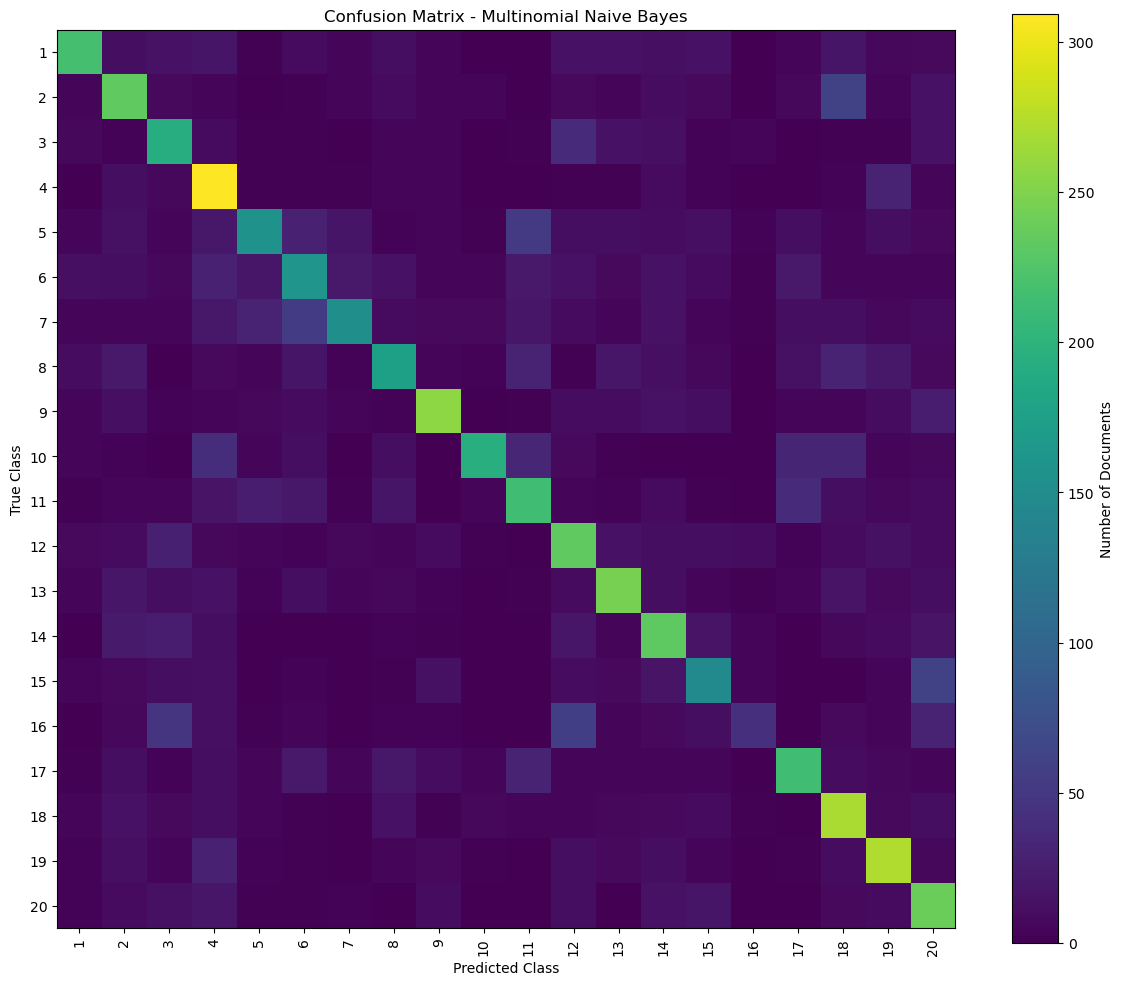

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
plt.imshow(confusion)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - Multinomial Naive Bayes")

plt.xticks(range(20), range(1, 21), rotation=90)
plt.yticks(range(20), range(1, 21))

plt.colorbar(label="Number of Documents")
plt.tight_layout()
plt.show()

## 2. Effect of stopword removal

## (a) Remove the stopwords from each document using the stopword list provided int ent.txt.

In [109]:
# tokenizer redefined
def tokenize_sw(text):
    text_body = text.split('\n\n')[1]
    text_words=text_body.lower().split()
    words=[]
    for word in text_words:
        word = word.strip(".,!?()[]:;")
        if word.isalpha() and len(word)>1:
            if word not in stopwords:
                words.append(word)
    return words

## (b) Train another Na¨ıve Bayes classifier (α = 1) on the stopword-removed documents and report its accuracy on the test set

In [110]:
#stop word removed training data
train_list_sw=[]
train_doc_count_sw=[]

for folder in sorted(os.listdir(TRAIN_DIR)):
    file_path=os.path.join(TRAIN_DIR,folder)
    file_list=os.listdir(file_path)

    file_tokens=[]
    train_doc_count_sw.append(len(file_list))

    for file in file_list:
        file_path_2=os.path.join(file_path,file)

        F=codecs.open(file_path_2,'r',encoding='utf-8',errors='ignore')
        content=F.read()

        tokens=tokenize_sw(content)

        file_tokens.extend(tokens)

    train_list_sw.append(file_tokens)

In [111]:
#stop word removed vocabulary
from collections import Counter

Vocabulary_sw=set()
word_counts_sw=[]

for cls in range(20):
    counts=Counter(train_list_sw[cls])
    word_counts_sw.append(counts)
    Vocabulary_sw.update(counts.keys())

V_sw=len(Vocabulary_sw)

In [112]:
# p(word/class) without stopword
probability_word_sw={}
ALPHA=1

for cls in range(20):
    total_word=len(train_list_sw[cls])
    counts=word_counts_sw[cls]

    for word in Vocabulary_sw:
        word_count=counts.get(word,0)

        probability=(word_count+ALPHA)/(total_word+ALPHA*V_sw)

        index=word+str(cls+1)
        probability_word_sw[index]=probability

In [113]:
#class probabilities without stopwords
probability_cls_sw={}

total_docs=sum(train_doc_count_sw)

for cls in range(20):
    probability_cls_sw[str(cls+1)]=train_doc_count_sw[cls]/total_docs

In [114]:
def predict_class(doc,probability_word,probability_cls):

    class_predict={}
    word_counts=Counter(doc)

    for cls_lbl in range(20):

        score=math.log(probability_cls[str(cls_lbl+1)])

        for word,count in word_counts.items():

            index=word+str(cls_lbl+1)

            if index in probability_word:
                score+=count*math.log(probability_word[index])

        class_predict[str(cls_lbl+1)]=score

    return class_predict
predictions_sw=[]

for doc in test_list_sw:
    scores=predict_class(doc,probability_word_sw,probability_cls_sw)

    predicted_class=max(scores,key=scores.get)

    predictions_sw.append(predicted_class)

In [115]:
test_list_sw=[]
test_labels_sw=[]

for cls,folder in enumerate(sorted(os.listdir(TEST_DIR))):
    file_path=os.path.join(TEST_DIR,folder)
    file_list=os.listdir(file_path)

    for file in file_list:
        file_path_2=os.path.join(file_path,file)

        F=codecs.open(file_path_2,'r',encoding='utf-8',errors='ignore')
        content=F.read()

        tokens=tokenize_sw(content)

        test_list_sw.append(tokens)
        test_labels_sw.append(str(cls+1))

In [116]:
#predictions
predictions_sw = []

for doc in test_list_sw:
    scores = predict_class_sw(doc)
    predicted_class = max(scores, key=scores.get)
    predictions_sw.append(predicted_class)

In [117]:
correct = 0

for true, pred in zip(test_labels_sw, predictions_sw):
    if true == pred:
        correct += 1

accuracy_sw = correct / len(test_labels_sw)

print("Accuracy:", accuracy_sw)
print("Accuracy (%):", accuracy_sw * 100)

Accuracy: 0.5722251725969199
Accuracy (%): 57.22251725969198


## (c) Plot the confusion matrix for this classifier.

In [118]:
import numpy as np

confusion_sw=np.zeros((20,20),dtype=int)

for true,pred in zip(test_labels_sw,predictions_sw):
    i=int(true)-1
    j=int(pred)-1
    confusion_sw[i][j]+=1

print(confusion_sw)

[[191   3   2   0   0   0   1   0   9   2   9   4   5  12  13  28  15  10
    5  10]
 [  6 158  23  18  14  21   4   3  17   4  50   9   6  11  13   4   6   8
   12   2]
 [  4  19 183  34   7  22   4   2  20  13  34   5   4   6   7   3   8   3
   10   6]
 [  5   3  29 229  26   2   7   2   8   9  33   0  15   2   3   2   9   4
    4   0]
 [  2   4  14  40 212   5   7   5  15   5  24  11  15   3   3   4   7   2
    7   0]
 [  3  37  24  22   8 168   5   8  13   9  62   4   1   2   5   3   9   4
    7   1]
 [  1   2   5  27  20   2 230  16   3   4  51   2  10   3   4   1   5   2
    2   0]
 [  8   0   4   2   2   2   9 261  27  10  18   1  15   6   6   4  11   2
    7   1]
 [  9   3   0   5   4   3   7  34 272   7   5   5  10   4   7   4  12   1
    6   0]
 [  4   2   3   2   1   1   2   7  22 271  37  10   0   4   3   8   9   5
    5   1]
 [  6   2   2   2   1   0   1   2  11  26 323   4   1   1   1   4   5   4
    3   0]
 [  7   7   7   2   7   2   3   1  21   6   7 274   7   3   5   2

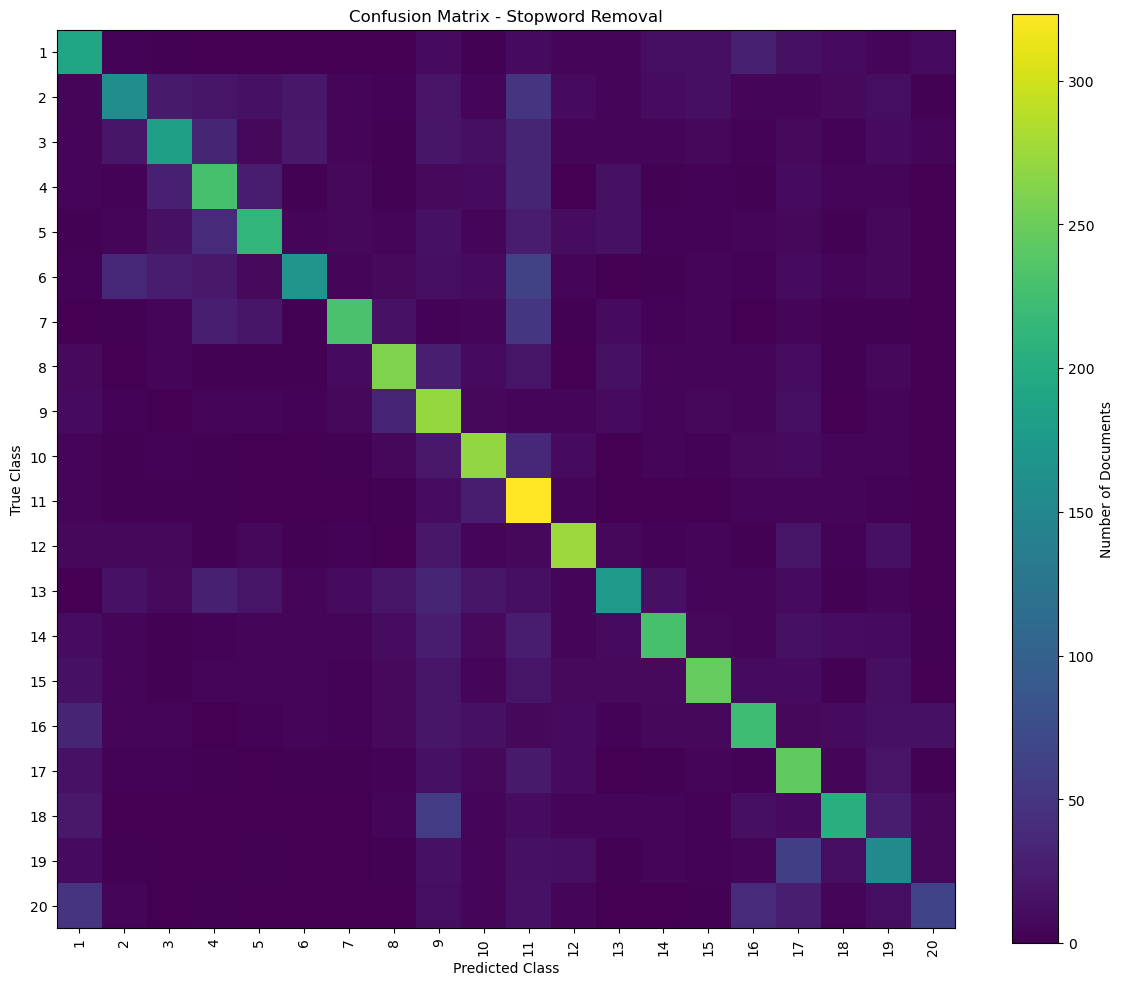

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
plt.imshow(confusion_sw)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - Stopword Removal")

plt.xticks(range(20),range(1,21),rotation=90)
plt.yticks(range(20),range(1,21))

plt.colorbar(label="Number of Documents")
plt.tight_layout()
plt.show()

## 3. Effect of the smoothing parameter

In [120]:
def get_probability_word(train_list,Vocabulary,ALPHA):

    probability_word={}
    word_counts=[]

    for cls in range(20):
        counts=Counter(train_list[cls])
        word_counts.append(counts)

    V=len(Vocabulary)

    for cls in range(20):
        total_word=len(train_list[cls])
        counts=word_counts[cls]

        for word in Vocabulary:
            word_count=counts.get(word,0)

            probability=(word_count+ALPHA)/(total_word+ALPHA*V)

            index=word+str(cls+1)
            probability_word[index]=probability

    return probability_word

In [121]:
alpha_values=[0.001,0.01,0.1,1,10]

accuracy_original=[]
accuracy_sw=[]

In [123]:
#orginal classifier
for ALPHA in alpha_values:

    probability_word=get_probability_word(
        train_list,
        Vocabulary,
        ALPHA
    )

    predictions=[]

    for doc in test_list:
        scores=predict_class(
            doc,
            probability_word,
            probability_cls
        )

        predicted_class=max(scores,key=scores.get)
        predictions.append(predicted_class)

    correct=0

    for true,pred in zip(test_labels,predictions):
        if true==pred:
            correct+=1

    accuracy=correct/len(test_labels)
    accuracy_original.append(accuracy)

    print("Alpha:",ALPHA)
    print("Accuracy:",accuracy*100)

Alpha: 0.001
Accuracy: 56.31970260223048
Alpha: 0.01
Accuracy: 57.23579394583113
Alpha: 0.1
Accuracy: 57.91290493892725
Alpha: 1
Accuracy: 55.27084439723845
Alpha: 10
Accuracy: 41.33032395114179


In [124]:
#stopword removed
for ALPHA in alpha_values:

    probability_word_sw=get_probability_word(
        train_list_sw,
        Vocabulary_sw,
        ALPHA
    )

    predictions_sw=[]

    for doc in test_list_sw:
        scores=predict_class(
            doc,
            probability_word_sw,
            probability_cls_sw
        )

        predicted_class=max(scores,key=scores.get)
        predictions_sw.append(predicted_class)

    correct=0

    for true,pred in zip(test_labels_sw,predictions_sw):
        if true==pred:
            correct+=1

    accuracy=correct/len(test_labels_sw)
    accuracy_sw.append(accuracy)

    print("Alpha:",ALPHA)
    print("Accuracy:",accuracy*100)

Alpha: 0.001
Accuracy: 56.027615507169415
Alpha: 0.01
Accuracy: 56.95698353690919
Alpha: 0.1
Accuracy: 58.218268720127455
Alpha: 1
Accuracy: 57.22251725969198
Alpha: 10
Accuracy: 52.70844397238449


In [125]:
#final comparision
print("Alpha\tOriginal\tStopword Removed")

for i in range(len(alpha_values)):
    print(
        alpha_values[i],
        "\t",
        accuracy_original[i]*100,
        "\t",
        accuracy_sw[i]*100
    )

Alpha	Original	Stopword Removed
0.001 	 56.31970260223048 	 56.027615507169415
0.01 	 57.23579394583113 	 56.95698353690919
0.1 	 57.91290493892725 	 58.218268720127455
1 	 55.27084439723845 	 57.22251725969198
10 	 41.33032395114179 	 52.70844397238449


#### Analysis

In [126]:
def get_f1(true_labels,predictions):

    f1_list=[]
    for cls in range(1,21):
        tp=0
        fp=0
        fn=0
        for true,pred in zip(true_labels,predictions):
            if int(true)==cls and int(pred)==cls:
                tp+=1
            elif int(true)!=cls and int(pred)==cls:
                fp+=1
            elif int(true)==cls and int(pred)!=cls:
                fn+=1
        if tp==0:
            f1=0
        else:
            precision=tp/(tp+fp)
            recall=tp/(tp+fn)

            f1=2*precision*recall/(precision+recall)
        f1_list.append(f1)

    return sum(f1_list)/len(f1_list)

In [127]:
f1_original=get_f1(test_labels,predictions)
f1_sw=get_f1(test_labels_sw,predictions_sw)

print("Original Accuracy:",accuracy_original[-1]*100)
print("Original F1:",f1_original)

print("Stopword Accuracy:",accuracy_sw[-1]*100)
print("Stopword F1:",f1_sw)

Original Accuracy: 41.33032395114179
Original F1: 0.4005257513654725
Stopword Accuracy: 52.70844397238449
Stopword F1: 0.5147661665339605


In [ ]:
5. Print the ten most probable words for each class from the trained Na¨

In [128]:
for cls in range(20):

    words=[]

    for word in Vocabulary:

        index=word+str(cls+1)

        words.append((word,probability_word[index]))

    words.sort(key=lambda x:x[1],reverse=True)

    print("Class",cls+1)

    for i in range(10):
        print(words[i][0],words[i][1])

Class 1
the 0.004965115632643985
to 0.0024981932399377365
in 0.0024391260840560375
of 0.002307093617967534
and 0.0018727762953079832
writes 0.0014593062041360907
is 0.0012855792750722703
that 0.001282104736490994
article 0.001136174116077385
for 0.001129225038914832
Class 2
the 0.004585429762087276
in 0.0024320896458487227
to 0.0023031679884040197
and 0.001804903204225843
writes 0.001648106593820123
of 0.0016097785334987247
article 0.0015087318290150386
is 0.0012927009435671577
it 0.0011951386082035987
on 0.0011707480243627088
Class 3
the 0.004385265507893478
of 0.002596493174238905
in 0.002475161717498769
to 0.002450895426150742
is 0.002235965417068216
that 0.0019690362122399174
writes 0.0017541062031573912
and 0.0017021070074116186
it 0.001414378124285011
article 0.001244514084848821
Class 4
the 0.006325387287934246
in 0.0027925362495997137
to 0.002313914130371156
of 0.0017251056239820672
and 0.0017251056239820672
writes 0.0013497832427165077
is 0.0012912467245374754
that 0.001212050